In [1]:
# Import 
import os
import numpy as np
from scipy.spatial import ConvexHull
from scipy.optimize import linear_sum_assignment
from itertools import permutations
import time
import pandas as pd
from joblib import dump, load
from pathlib import Path

## sourceXray
from src.sourceXray_BJ import sourceXray, compute_C, solve_H_right_inverse
from src.utils import *
from src.simulate_nmf import simulate_dataset

## N-FINDR
from src.NFINDR import nfindr_BJ

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# settings
K = 5
J = 10
n_reps = 50
n_list = [100, 300, 1500, 10000, 100000, 500000]

# path 
outdir = Path("results/sims")
outdir.mkdir(parents=True, exist_ok=True)

In [4]:
# # container to hold *all* results in memory
# # results[n] -> dict of arrays (each of length n_reps)
# results = {}

# for n in [100, 300, 1500]:
#     print(f"\n=== Running experiments for n = {n} ===\n")

#     # allocate per-n arrays
#     per_n = {
#         # time
#         "time_exact_sourceXray": np.zeros(n_reps),
#         "time_random_sourceXray": np.zeros(n_reps),
#         "time_sourceXray_10K": np.zeros(n_reps),
#         "time_sourceXray_15K": np.zeros(n_reps),
#         "time_nfindr": np.zeros(n_reps),

#         # H metrics
#         "H_rmssad_exact_sourceXray": np.zeros(n_reps),
#         "H_fro_exact_sourceXray": np.zeros(n_reps),
#         "H_nrmse_exact_sourceXray": np.zeros(n_reps),
#         "H_rmssad_random_sourceXray": np.zeros(n_reps),
#         "H_fro_random_sourceXray": np.zeros(n_reps),
#         "H_nrmse_random_sourceXray": np.zeros(n_reps),
#         "H_rmssad_sourceXray_10K": np.zeros(n_reps),
#         "H_fro_sourceXray_10K": np.zeros(n_reps),
#         "H_nrmse_sourceXray_10K": np.zeros(n_reps),
#         "H_rmssad_sourceXray_15K": np.zeros(n_reps),
#         "H_fro_sourceXray_15K": np.zeros(n_reps),
#         "H_nrmse_sourceXray_15K": np.zeros(n_reps),
#         "H_rmssad_nfindr": np.zeros(n_reps),
#         "H_fro_nfindr": np.zeros(n_reps),
#         "H_nrmse_nfindr": np.zeros(n_reps),

#         # C metrics
#         "C_fro_exact_sourceXray": np.zeros(n_reps),
#         "C_nrmse_exact_sourceXray": np.zeros(n_reps),
#         "C_fro_random_sourceXray": np.zeros(n_reps),
#         "C_nrmse_random_sourceXray": np.zeros(n_reps),
#         "C_fro_sourceXray_10K": np.zeros(n_reps),
#         "C_nrmse_sourceXray_10K": np.zeros(n_reps),
#         "C_fro_sourceXray_15K": np.zeros(n_reps),
#         "C_nrmse_sourceXray_15K": np.zeros(n_reps),
#         "C_fro_nfindr": np.zeros(n_reps),
#         "C_nrmse_nfindr": np.zeros(n_reps),
#     }
    
#     est_per_n = {
#         "logvol_exact_sourceXray": np.zeros(n_reps),
#         "logvol_random_sourceXray": np.zeros(n_reps),
#         "logvol_sourceXray_10K": np.zeros(n_reps),
#         "logvol_sourceXray_15K": np.zeros(n_reps),
#         "refined_10K": np.zeros(n_reps),
#         "refined_15K": np.zeros(n_reps),

#         "C_hat_exact_sourceXray": np.empty((n_reps, J, K), dtype=float),
#         "C_hat_random_sourceXray": np.empty((n_reps, J, K), dtype=float),
#         "C_hat_sourceXray_10K": np.empty((n_reps, J, K), dtype=float),
#         "C_hat_sourceXray_15K": np.empty((n_reps, J, K), dtype=float),
#         "C_hat_nfindr": np.empty((n_reps, J, K), dtype=float),

#         "H_star_hat_exact_sourceXray": np.empty((n_reps, K, J), dtype=float),
#         "H_star_hat_random_sourceXray": np.empty((n_reps, K, J), dtype=float),
#         "H_star_hat_sourceXray_10K": np.empty((n_reps, K, J), dtype=float),
#         "H_star_hat_sourceXray_15K": np.empty((n_reps, K, J), dtype=float),
#         "H_star_hat_nfindr": np.empty((n_reps, K, J), dtype=float),

#         "C": np.empty((n_reps, J, K), dtype=float),
#         "H_star": np.empty((n_reps, K, J), dtype=float),
#     }

#     for rep in range(n_reps):
#         print(f"n={n}, rep {rep+1}/{n_reps}", flush=True)
        
#         # simulate data 
#         seed = n+rep
#         Y, Y_star, r, H, H_star, W, mu, W_tilde, mu_tilde, W_star, C, C_alt = simulate_dataset(n=n, K=K, J=J, seed=seed, process="iid")
#         est_per_n["C"][rep] = C
#         est_per_n["H_star"][rep] = H_star

#         # ---------- exact sourceXray ----------
#         t0 = time.time()
#         H_star_hat, W_tilde_hat, mu_tilde_hat, C_hat, logvol_hat = sourceXray(Y, K, seed=seed, prune=False, verbose=False)[0]
#         t1 = time.time()
#         per_n["time_exact_sourceXray"][rep] = t1 - t0
#         est_per_n["logvol_exact_sourceXray"][rep] = logvol_hat

#         # permute to match truth
#         H_star_hat_perm, mu_tilde_hat_perm, C_hat_perm, _ = \
#             permute_estimates_to_match_truth(H_star, H_star_hat, mu_tilde_hat, C_hat)
#         est_per_n["C_hat_exact_sourceXray"][rep] = C_hat_perm
#         est_per_n["H_star_hat_exact_sourceXray"][rep] = H_star_hat_perm

#         # metrics (H)
#         per_n["H_rmssad_exact_sourceXray"][rep] = rms_sad(H_star, H_star_hat_perm)['rms_sad']
#         per_n["H_fro_exact_sourceXray"][rep] = frobenius_dist(H_star, H_star_hat_perm, relative=True)
#         per_n["H_nrmse_exact_sourceXray"][rep] = nrmse(H_star, H_star_hat_perm)['nrmse']

#         # metrics (C)
#         per_n["C_fro_exact_sourceXray"][rep] = frobenius_dist(C, C_hat_perm, relative=True)
#         per_n["C_nrmse_exact_sourceXray"][rep] = nrmse(C, C_hat_perm)['nrmse']

#         # ---------- sourceXray (direction) ----------
#         t0 = time.time()
#         H_star_hat, W_tilde_hat, mu_tilde_hat, C_hat, logvol_hat = sourceXray(Y, K, seed=seed, 
#                                                                               candidate_method="random", 
#                                                                               T=20000, topk=1, max_K=200*K, 
#                                                                               prune=False, verbose=False)[0]
#         t1 = time.time()
#         per_n["time_random_sourceXray"][rep] = t1 - t0
#         est_per_n["logvol_random_sourceXray"][rep] = logvol_hat

#         # permute to match truth
#         H_star_hat_perm, mu_tilde_hat_perm, C_hat_perm, _ = \
#             permute_estimates_to_match_truth(H_star, H_star_hat, mu_tilde_hat, C_hat)
#         est_per_n["C_hat_random_sourceXray"][rep] = C_hat_perm
#         est_per_n["H_star_hat_random_sourceXray"][rep] = H_star_hat_perm

#         # metrics (H)
#         per_n["H_rmssad_random_sourceXray"][rep] = rms_sad(H_star, H_star_hat_perm)['rms_sad']
#         per_n["H_fro_random_sourceXray"][rep] = frobenius_dist(H_star, H_star_hat_perm, relative=True)
#         per_n["H_nrmse_random_sourceXray"][rep] = nrmse(H_star, H_star_hat_perm)['nrmse']

#         # metrics (C)
#         per_n["C_fro_random_sourceXray"][rep] = frobenius_dist(C, C_hat_perm, relative=True)
#         per_n["C_nrmse_random_sourceXray"][rep] = nrmse(C, C_hat_perm)['nrmse']

#         # ---------- sourceXray (direction + prune + refinement, 10K) ----------
#         t0 = time.time()
#         geo_out, fit_diagnostics = sourceXray(Y, K, seed=seed, 
#                                               candidate_method="random", 
#                                               T=20000, topk=1, max_K=200*K, 
#                                               prune=True, min_K=10*K,
#                                               refine_greedy=True,
#                                               return_fit_diagnostics=True,
#                                               verbose=False)                                        
#         t1 = time.time()
#         H_star_hat, W_tilde_hat, mu_tilde_hat, C_hat, logvol_hat = geo_out[0]
#         per_n["time_sourceXray_10K"][rep] = t1 - t0
#         est_per_n["logvol_sourceXray_10K"][rep] = logvol_hat
#         est_per_n["refined_10K"][rep] = (logvol_hat > fit_diagnostics["logvol_before_refinement"])

#         # permute to match truth
#         H_star_hat_perm, mu_tilde_hat_perm, C_hat_perm, _ = \
#             permute_estimates_to_match_truth(H_star, H_star_hat, mu_tilde_hat, C_hat)
#         est_per_n["C_hat_sourceXray_10K"][rep] = C_hat_perm
#         est_per_n["H_star_hat_sourceXray_10K"][rep] = H_star_hat_perm

#         # metrics (H)
#         per_n["H_rmssad_sourceXray_10K"][rep] = rms_sad(H_star, H_star_hat_perm)['rms_sad']
#         per_n["H_fro_sourceXray_10K"][rep] = frobenius_dist(H_star, H_star_hat_perm, relative=True)
#         per_n["H_nrmse_sourceXray_10K"][rep] = nrmse(H_star, H_star_hat_perm)['nrmse']

#         # metrics (C)
#         per_n["C_fro_sourceXray_10K"][rep] = frobenius_dist(C, C_hat_perm, relative=True)
#         per_n["C_nrmse_sourceXray_10K"][rep] = nrmse(C, C_hat_perm)['nrmse']

#         # ---------- sourceXray (direction + prune + refinement, 15K) ----------
#         t0 = time.time()
#         geo_out, fit_diagnostics = sourceXray(Y, K, seed=seed, 
#                                               candidate_method="random", 
#                                               T=20000, topk=1, max_K=200*K, 
#                                               prune=True, min_K=15*K,
#                                               refine_greedy=True,
#                                               return_fit_diagnostics=True,
#                                               verbose=False)   
#         t1 = time.time()
#         H_star_hat, W_tilde_hat, mu_tilde_hat, C_hat, logvol_hat = geo_out[0]
#         per_n["time_sourceXray_15K"][rep] = t1 - t0
#         est_per_n["logvol_sourceXray_15K"][rep] = logvol_hat
#         est_per_n["refined_15K"][rep] = (logvol_hat > fit_diagnostics["logvol_before_refinement"])

#         # permute to match truth
#         H_star_hat_perm, mu_tilde_hat_perm, C_hat_perm, _ = \
#             permute_estimates_to_match_truth(H_star, H_star_hat, mu_tilde_hat, C_hat)
#         est_per_n["C_hat_sourceXray_15K"][rep] = C_hat_perm
#         est_per_n["H_star_hat_sourceXray_15K"][rep] = H_star_hat_perm

#         # metrics (H)
#         per_n["H_rmssad_sourceXray_15K"][rep] = rms_sad(H_star, H_star_hat_perm)['rms_sad']
#         per_n["H_fro_sourceXray_15K"][rep] = frobenius_dist(H_star, H_star_hat_perm, relative=True)
#         per_n["H_nrmse_sourceXray_15K"][rep] = nrmse(H_star, H_star_hat_perm)['nrmse']

#         # metrics (C)
#         per_n["C_fro_sourceXray_15K"][rep] = frobenius_dist(C, C_hat_perm, relative=True)
#         per_n["C_nrmse_sourceXray_15K"][rep] = nrmse(C, C_hat_perm)['nrmse']

#         # ---------- N-FINDR ----------
#         t0 = time.time()
#         H_star_hat_nfindr, _ = nfindr_BJ(Y_star, K, max_iter=5, seed=seed, normalize=False, init='atgp')
#         W_star_hat_nfindr, _, _ = solve_H_right_inverse(Y_star, H_star_hat_nfindr)
#         W_tilde_hat_nfindr = W_star_hat_nfindr * r
#         mu_tilde_hat_nfindr = W_tilde_hat_nfindr.mean(axis=0)
#         C_hat_nfindr = compute_C(mu_tilde_hat_nfindr, H_star_hat_nfindr)
#         t1 = time.time()
#         per_n["time_nfindr"][rep] = t1 - t0

#         # permute to match truth
#         H_star_hat_perm_nfindr, mu_tilde_hat_perm_nfindr, C_hat_perm_nfindr, _ = (
#             permute_estimates_to_match_truth(H_star, H_star_hat_nfindr, mu_tilde_hat_nfindr, C_hat_nfindr)
#         )
#         est_per_n["C_hat_nfindr"][rep] = C_hat_perm_nfindr
#         est_per_n["H_star_hat_nfindr"][rep] = H_star_hat_perm_nfindr
        
#         # metrics (H)
#         per_n["H_rmssad_nfindr"][rep] = rms_sad(H_star, H_star_hat_perm_nfindr)['rms_sad']
#         per_n["H_fro_nfindr"][rep] = frobenius_dist(H_star, H_star_hat_perm_nfindr, relative=True)
#         per_n["H_nrmse_nfindr"][rep] = nrmse(H_star, H_star_hat_perm_nfindr)['nrmse']

#         # metrics (C)
#         per_n["C_fro_nfindr"][rep] = frobenius_dist(C, C_hat_perm_nfindr, relative=True)
#         per_n["C_nrmse_nfindr"][rep] = nrmse(C, C_hat_perm_nfindr)['nrmse']

#     # stash arrays for this n
#     results[n] = {
#         "metrics": per_n,
#         "estimates": est_per_n
#     }
    
#     # save
#     dump(results[n], outdir/f"sourceXray_convergence_sims_iidW_J10K5_n{n}.joblib")

In [5]:
# for n in [10000, 100000, 500000]:
#     print(f"\n=== Running experiments for n = {n} ===\n")

#     # allocate per-n arrays
#     per_n = {
#         # time
#         "time_sourceXray_10K": np.zeros(n_reps),
#         "time_sourceXray_15K": np.zeros(n_reps),
#         "time_nfindr": np.zeros(n_reps),

#         # H metrics
#         "H_rmssad_sourceXray_10K": np.zeros(n_reps),
#         "H_fro_sourceXray_10K": np.zeros(n_reps),
#         "H_nrmse_sourceXray_10K": np.zeros(n_reps),
#         "H_rmssad_sourceXray_15K": np.zeros(n_reps),
#         "H_fro_sourceXray_15K": np.zeros(n_reps),
#         "H_nrmse_sourceXray_15K": np.zeros(n_reps),
#         "H_rmssad_nfindr": np.zeros(n_reps),
#         "H_fro_nfindr": np.zeros(n_reps),
#         "H_nrmse_nfindr": np.zeros(n_reps),

#         # C metrics
#         "C_fro_sourceXray_10K": np.zeros(n_reps),
#         "C_nrmse_sourceXray_10K": np.zeros(n_reps),
#         "C_fro_sourceXray_15K": np.zeros(n_reps),
#         "C_nrmse_sourceXray_15K": np.zeros(n_reps),
#         "C_fro_nfindr": np.zeros(n_reps),
#         "C_nrmse_nfindr": np.zeros(n_reps),
#     }
    
#     est_per_n = {
#         "logvol_sourceXray_10K": np.zeros(n_reps),
#         "logvol_sourceXray_15K": np.zeros(n_reps),
#         "refined_10K": np.zeros(n_reps),
#         "refined_15K": np.zeros(n_reps),

#         "C_hat_sourceXray_10K": np.empty((n_reps, J, K), dtype=float),
#         "C_hat_sourceXray_15K": np.empty((n_reps, J, K), dtype=float),
#         "C_hat_nfindr": np.empty((n_reps, J, K), dtype=float),

#         "H_star_hat_sourceXray_10K": np.empty((n_reps, K, J), dtype=float),
#         "H_star_hat_sourceXray_15K": np.empty((n_reps, K, J), dtype=float),
#         "H_star_hat_nfindr": np.empty((n_reps, K, J), dtype=float),

#         "C": np.empty((n_reps, J, K), dtype=float),
#         "H_star": np.empty((n_reps, K, J), dtype=float),
#     }

#     for rep in range(n_reps):
#         print(f"n={n}, rep {rep+1}/{n_reps}", flush=True)
        
#         # simulate data 
#         seed = n+rep
#         Y, Y_star, r, H, H_star, W, mu, W_tilde, mu_tilde, W_star, C, C_alt = simulate_dataset(n=n, K=K, J=J, seed=seed, process="iid")
#         est_per_n["C"][rep] = C
#         est_per_n["H_star"][rep] = H_star

#         # ---------- sourceXray (direction + prune + refinement, 10K) ----------
#         t0 = time.time()
#         geo_out, fit_diagnostics = sourceXray(Y, K, seed=seed, 
#                                               candidate_method="random", 
#                                               T=20000, topk=1, max_K=200*K, 
#                                               prune=True, min_K=10*K,
#                                               refine_greedy=True,
#                                               return_fit_diagnostics=True,
#                                               verbose=False)                                        
#         t1 = time.time()
#         H_star_hat, W_tilde_hat, mu_tilde_hat, C_hat, logvol_hat = geo_out[0]
#         per_n["time_sourceXray_10K"][rep] = t1 - t0
#         est_per_n["logvol_sourceXray_10K"][rep] = logvol_hat
#         est_per_n["refined_10K"][rep] = (logvol_hat > fit_diagnostics["logvol_before_refinement"])

#         # permute to match truth
#         H_star_hat_perm, mu_tilde_hat_perm, C_hat_perm, _ = \
#             permute_estimates_to_match_truth(H_star, H_star_hat, mu_tilde_hat, C_hat)
#         est_per_n["C_hat_sourceXray_10K"][rep] = C_hat_perm
#         est_per_n["H_star_hat_sourceXray_10K"][rep] = H_star_hat_perm

#         # metrics (H)
#         per_n["H_rmssad_sourceXray_10K"][rep] = rms_sad(H_star, H_star_hat_perm)['rms_sad']
#         per_n["H_fro_sourceXray_10K"][rep] = frobenius_dist(H_star, H_star_hat_perm, relative=True)
#         per_n["H_nrmse_sourceXray_10K"][rep] = nrmse(H_star, H_star_hat_perm)['nrmse']

#         # metrics (C)
#         per_n["C_fro_sourceXray_10K"][rep] = frobenius_dist(C, C_hat_perm, relative=True)
#         per_n["C_nrmse_sourceXray_10K"][rep] = nrmse(C, C_hat_perm)['nrmse']

#         # ---------- sourceXray (direction + prune + refinement, 15K) ----------
#         t0 = time.time()
#         geo_out, fit_diagnostics = sourceXray(Y, K, seed=seed, 
#                                               candidate_method="random", 
#                                               T=20000, topk=1, max_K=200*K, 
#                                               prune=True, min_K=15*K,
#                                               refine_greedy=True,
#                                               return_fit_diagnostics=True,
#                                               verbose=False)   
#         t1 = time.time()
#         H_star_hat, W_tilde_hat, mu_tilde_hat, C_hat, logvol_hat = geo_out[0]
#         per_n["time_sourceXray_15K"][rep] = t1 - t0
#         est_per_n["logvol_sourceXray_15K"][rep] = logvol_hat
#         est_per_n["refined_15K"][rep] = (logvol_hat > fit_diagnostics["logvol_before_refinement"])

#         # permute to match truth
#         H_star_hat_perm, mu_tilde_hat_perm, C_hat_perm, _ = \
#             permute_estimates_to_match_truth(H_star, H_star_hat, mu_tilde_hat, C_hat)
#         est_per_n["C_hat_sourceXray_15K"][rep] = C_hat_perm
#         est_per_n["H_star_hat_sourceXray_15K"][rep] = H_star_hat_perm

#         # metrics (H)
#         per_n["H_rmssad_sourceXray_15K"][rep] = rms_sad(H_star, H_star_hat_perm)['rms_sad']
#         per_n["H_fro_sourceXray_15K"][rep] = frobenius_dist(H_star, H_star_hat_perm, relative=True)
#         per_n["H_nrmse_sourceXray_15K"][rep] = nrmse(H_star, H_star_hat_perm)['nrmse']

#         # metrics (C)
#         per_n["C_fro_sourceXray_15K"][rep] = frobenius_dist(C, C_hat_perm, relative=True)
#         per_n["C_nrmse_sourceXray_15K"][rep] = nrmse(C, C_hat_perm)['nrmse']

#         # ---------- N-FINDR ----------
#         t0 = time.time()
#         H_star_hat_nfindr, _ = nfindr_BJ(Y_star, K, max_iter=5, seed=seed, normalize=False, init='atgp')
#         W_star_hat_nfindr, _, _ = solve_H_right_inverse(Y_star, H_star_hat_nfindr)
#         W_tilde_hat_nfindr = W_star_hat_nfindr * r
#         mu_tilde_hat_nfindr = W_tilde_hat_nfindr.mean(axis=0)
#         C_hat_nfindr = compute_C(mu_tilde_hat_nfindr, H_star_hat_nfindr)
#         t1 = time.time()
#         per_n["time_nfindr"][rep] = t1 - t0

#         # permute to match truth
#         H_star_hat_perm_nfindr, mu_tilde_hat_perm_nfindr, C_hat_perm_nfindr, _ = (
#             permute_estimates_to_match_truth(H_star, H_star_hat_nfindr, mu_tilde_hat_nfindr, C_hat_nfindr)
#         )
#         est_per_n["C_hat_nfindr"][rep] = C_hat_perm_nfindr
#         est_per_n["H_star_hat_nfindr"][rep] = H_star_hat_perm_nfindr
        
#         # metrics (H)
#         per_n["H_rmssad_nfindr"][rep] = rms_sad(H_star, H_star_hat_perm_nfindr)['rms_sad']
#         per_n["H_fro_nfindr"][rep] = frobenius_dist(H_star, H_star_hat_perm_nfindr, relative=True)
#         per_n["H_nrmse_nfindr"][rep] = nrmse(H_star, H_star_hat_perm_nfindr)['nrmse']

#         # metrics (C)
#         per_n["C_fro_nfindr"][rep] = frobenius_dist(C, C_hat_perm_nfindr, relative=True)
#         per_n["C_nrmse_nfindr"][rep] = nrmse(C, C_hat_perm_nfindr)['nrmse']

#     # stash arrays for this n
#     results[n] = {
#         "metrics": per_n,
#         "estimates": est_per_n
#     }
    
#     # save
#     dump(results[n], outdir/f"sourceXray_convergence_sims_iidW_J10K5_n{n}.joblib")

In [6]:
# dump(results, outdir/"sourceXray_convergence_sims_iidW_J10K5.joblib")

In [7]:
results = load("results/sims/sourceXray_convergence_sims_iidW_J10K5.joblib")

# Collect the union of metric keys across all n's (since some n's have fewer metrics)
all_metric_keys = sorted({
    k
    for bundle in results.values()
    for k in bundle["metrics"].keys()
})

# Long table: one row per (n, rep), columns for all metrics (NaN if missing)
records = []
for n, bundle in results.items():
    per_n = bundle["metrics"]
    for rep in range(n_reps):
        rec = {"n": n, "rep": rep}
        for mk in all_metric_keys:
            arr = per_n.get(mk, None)
            rec[mk] = (arr[rep] if arr is not None and rep < len(arr) else np.nan)
        records.append(rec)

df_long = pd.DataFrame.from_records(records).sort_values(["n", "rep"]).reset_index(drop=True)

for target in ["H", "C"]:
    for metric in ["nrmse", "fro"]:
        col_sx    = f"{target}_{metric}_sourceXray_10K"
        col_nf    = f"{target}_{metric}_nfindr"
        col_delta = f"delta_{target}_{metric}"   
        delta     = df_long[col_nf] - df_long[col_sx] # >0 means sourceXray wins
        df_long[col_delta] = delta
        df_long[f"{target}_{metric}_win"] = (delta > 0)

# Per-n summary: mean and std across reps (numeric cols only)
metric_cols = [c for c in df_long.columns if c not in ("n", "rep")]

summary_mean = (
    df_long.groupby("n", as_index=False)[metric_cols]
    .mean(numeric_only=True)
    .rename(columns={c: f"{c}_mean" for c in metric_cols})
)

summary_median = (
    df_long.groupby("n", as_index=False)[metric_cols]
    .median(numeric_only=True)
    .rename(columns={c: f"{c}_median" for c in metric_cols})
)

summary_std = (
    df_long.groupby("n", as_index=False)[metric_cols]
    .std(ddof=1, numeric_only=True)
    .rename(columns={c: f"{c}_std" for c in metric_cols})
)

# merge mean, median, and std on n
df_summary = (
    summary_mean
    .merge(summary_median, on="n", how="left")
    .merge(summary_std, on="n", how="left")
)

### Refinement acceptance rate

In [8]:
# ── proportion of reps where greedy refinement improved log-volume ───────────
ref_cols = {
    "refined_10K": "10K",
    "refined_15K": "15K",
}

rows = []
for n, res in results.items():
    for col, label in ref_cols.items():
        arr = res["estimates"][col]          # shape (n_reps,) boolean/float
        rows.append({
            "n":      n,
            "prune":  label,
            "pct":    arr.mean() * 100,    # % reps refined
            "count":  arr.sum(),
        })

df_refined = pd.DataFrame(rows)
print(df_refined.to_string(index=False))

     n prune  pct  count
   100   10K  0.0    0.0
   100   15K  0.0    0.0
   300   10K 14.0    7.0
   300   15K  0.0    0.0
  1500   10K 52.0   26.0
  1500   15K 10.0    5.0
 10000   10K 84.0   42.0
 10000   15K 32.0   16.0
100000   10K 96.0   48.0
100000   15K 60.0   30.0
500000   10K 94.0   47.0
500000   15K 68.0   34.0


In [9]:
REFINED = {
    "10K": ("Exhaustive (random direction + pruned 10K)", "#E24B4A", "-"),
    "15K": ("Exhaustive (random direction + pruned 15K)", "#854F0B", "-."),
}

### Run time

In [10]:
TIME = {
    "time_exact_sourceXray_mean":  ("Exhaustive (exact)", "#BA7517", ":"),
    "time_random_sourceXray_mean": ("Exhaustive (random direction)", "#EF9F27", "--"),
    "time_sourceXray_10K_mean":    ("Exhaustive (random direction + pruned 10K)", "#E24B4A", "-"),
    "time_sourceXray_15K_mean":    ("Exhaustive (random direction + pruned 15K)", "#854F0B", "-."),
    "time_nfindr_mean":            ("Greedy", "#1D9E75", "-"),
}

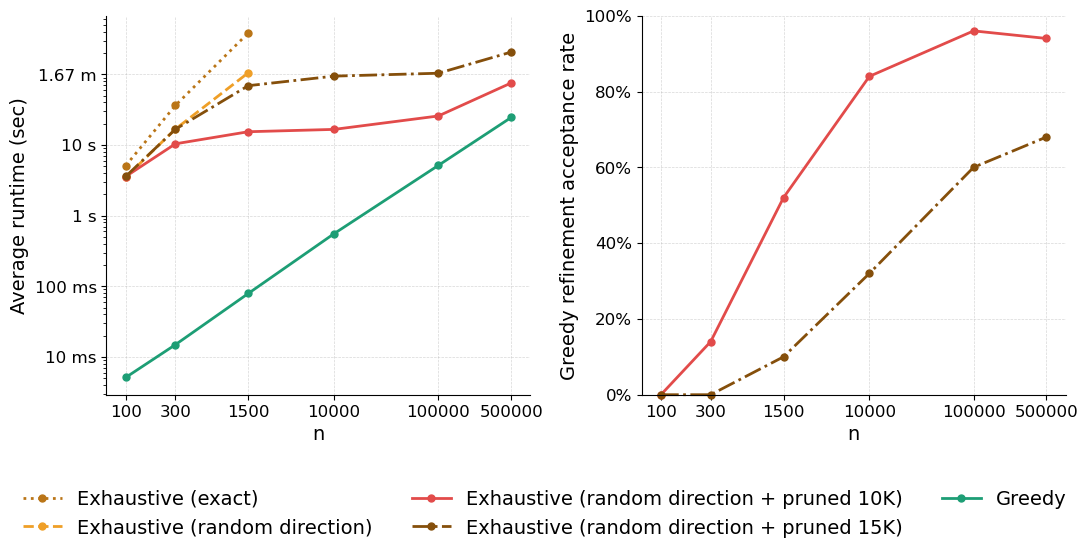

In [11]:
import matplotlib.ticker as ticker

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
 
# ── left: runtime ─────────────────────────────────────────────────────────────
ns_time = df_summary["n"].values
 
for col, (label, color, ls) in TIME.items():
    if col not in df_summary.columns:
        continue
    vals = df_summary[col].values.astype(float)
    mask = ~np.isnan(vals) & (vals > 0)
    ax1.plot(ns_time[mask], vals[mask],
             label=label, color=color, linestyle=ls,
             linewidth=2, marker="o", markersize=5, clip_on=False)
 
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("n", fontsize=14)
ax1.set_ylabel("Average runtime (sec)", fontsize=14)
ax1.set_xticks(ns_time)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):}"))
ax1.tick_params(axis="both", which="major", labelsize=12)
ax1.tick_params(axis="x", which="minor", bottom=False)
ax1.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, _: (
        f"{y*1000:.3g} ms" if y < 1
        else f"{y:.3g} s"  if y < 60
        else f"{y/60:.3g} m"
    ))
)
ax1.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.5)
ax1.spines[["top", "right"]].set_visible(False)
 
# ── right: refinement acceptance ──────────────────────────────────────────────
ns_ref = df_refined["n"].sort_values().unique()
 
for prune, (label, color, ls) in REFINED.items():
    sub = df_refined[df_refined["prune"] == prune].sort_values("n")
    ax2.plot(sub["n"], sub["pct"],
             label=label, color=color, linestyle=ls,
             linewidth=2, marker="o", markersize=5, clip_on=False)
 
ax2.set_xscale("log")
ax2.set_xticks(ns_ref)
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):}"))
ax2.tick_params(axis="both", which="major", labelsize=12)
ax2.tick_params(axis="x", which="minor", bottom=False)
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{int(y)}%"))
ax2.set_xlabel("n", fontsize=14)
ax2.set_ylabel("Greedy refinement acceptance rate", fontsize=14)
ax2.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.5)
ax2.spines[["top", "right"]].set_visible(False)
 
# ── shared legend at bottom ───────────────────────────────────────────────────
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
 
# deduplicate by label
seen, handles, labels = set(), [], []
for h, l in zip(handles1 + handles2, labels1 + labels2):
    if l not in seen:
        seen.add(l)
        handles.append(h)
        labels.append(l)
 
fig.legend(handles, labels,
           loc="lower center", bbox_to_anchor=(0.5, -0.12),
           ncol=3, frameon=False, fontsize=14)
 
fig.tight_layout()
fig.subplots_adjust(bottom=0.2)
 
# fig.savefig(outdir/"figure/sourceXray_convergence_sims_iidW_J10K5_runtime_acceptrate.pdf", dpi=150, bbox_inches="tight")
plt.show()

### Estimation accuracy

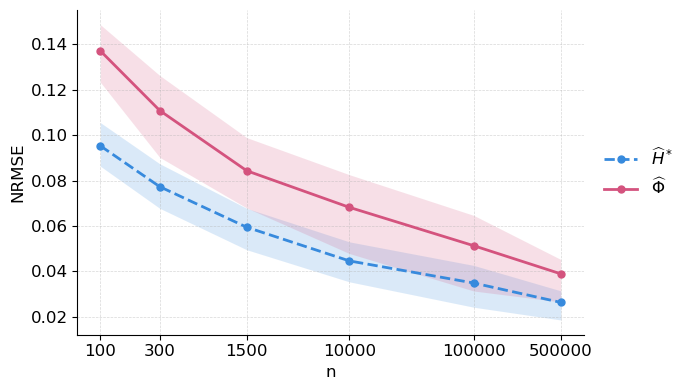

In [12]:
SERIES = {
    "H_nrmse_sourceXray_10K": (r"$\widehat{H}^*$",   "#378ADD", "--"),
    "C_nrmse_sourceXray_10K": (r"$\widehat{\Phi}$", "#D4537E", "-"),
}
 
fig, ax = plt.subplots(figsize=(7, 4))
 
for col, (label, color, ls) in SERIES.items():
    ns = sorted(df_long["n"].unique())
    means, lo, hi = [], [], []
 
    for n in ns:
        vals = df_long.loc[df_long["n"] == n, col].dropna().values
        means.append(vals.mean())
        lo.append(np.percentile(vals, 25))
        hi.append(np.percentile(vals, 75))
 
    ns    = np.array(ns)
    means = np.array(means)
    lo    = np.array(lo)
    hi    = np.array(hi)
 
    ax.fill_between(ns, lo, hi, color=color, alpha=0.18, linewidth=0)
    ax.plot(ns, means, color=color, linestyle=ls, linewidth=2,
            marker="o", markersize=5, label=label, clip_on=False)
 
# ── axes ─────────────────────────────────────────────────────────────────────
ns = np.array(sorted(df_long["n"].unique()))
ax.set_xscale("log")
ax.set_xlabel("n", fontsize=12)
ax.set_ylabel("NRMSE", fontsize=12)
ax.set_xticks(ns)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):}"))
ax.tick_params(axis="both", which="major", labelsize=12)
ax.tick_params(axis="x", which="minor", length=0)
ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
 
# ── legend ────────────────────────────────────────────────────────────────────
ax.legend(frameon=False, fontsize=12, loc="center left",
          bbox_to_anchor=(1.01, 0.5))
 
fig.tight_layout()
 
# fig.savefig(outdir/"figure/sourceXray_convergence_sims_iidW_J10K5_NRMSE.pdf", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
dct_C = {}
for n in n_list:
    # stash arrays for this n
    dct_C[n] = {
        "true": results[n]["estimates"]["C"], 
        "hat_nfindr": results[n]["estimates"]["C_hat_sourceXray_10K"],
    }

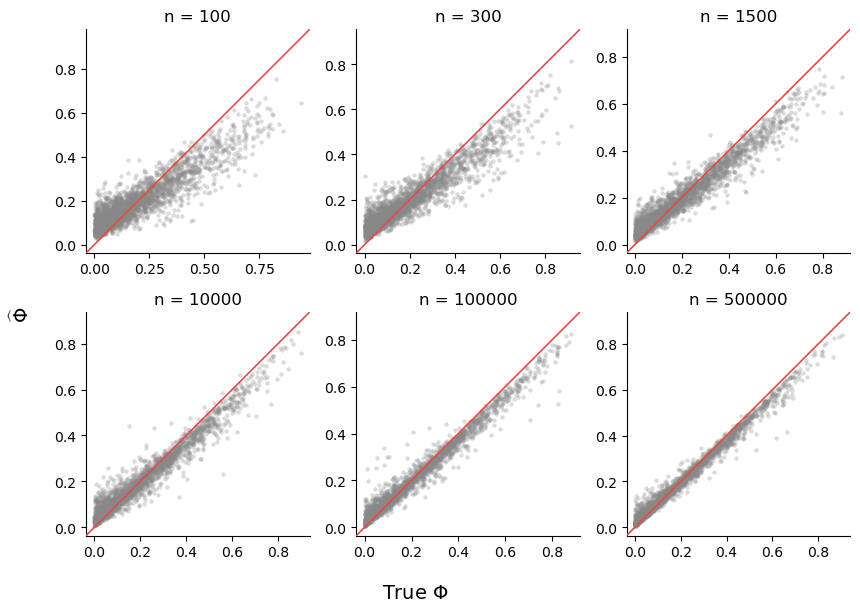

In [14]:
ns     = sorted(dct_C.keys())
nrow, ncol = 2, 3
 
fig, axes = plt.subplots(nrow, ncol, figsize=(3 * ncol, 3.2 * nrow))
axes_flat = axes.flatten()

for ax, n in zip(axes_flat, ns):
    true = dct_C[n]["true"].ravel()        # flatten all reps × entries
    hat  = dct_C[n]["hat_nfindr"].ravel()

    mask = ~(np.isnan(true) | np.isnan(hat))
    true, hat = true[mask], hat[mask]

    ax.scatter(true, hat, s=10, color="#888888", alpha=0.3,
                linewidths=0, rasterized=True)

    # 45-degree reference line
    lo = min(true.min(), hat.min())
    hi = max(true.max(), hat.max())
    pad = (hi - lo) * 0.04
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
            color="#E24B4A", linewidth=1.2, zorder=3)

    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect("equal", adjustable="box")

    ax.set_title(f"n = {n:}", fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=10)

# hide any unused panels (if fewer than 6 values of n)
for ax in axes_flat[len(ns):]:
    ax.set_visible(False)

fig.supxlabel(r"True $\Phi$", fontsize=14, y=0.05)
fig.supylabel(r"$\widehat \Phi$", fontsize=14, x=0.05)

fig.tight_layout(rect=[0.04, 0.04, 1, 1])

# fig.savefig(outdir/"figure/sourceXray_convergence_sims_iidW_J10K5_PhiScatter.pdf", dpi=150, bbox_inches="tight")
plt.show()

### $H^*$

In [15]:
def plot_single_scatter(
    Y,
    i,  # row index (y-axis variable)
    j,  # col index (x-axis variable)
    H=None,
    H_hat=None,
    alpha=0.5,
    point_size=30,
    convexhull=True,
    title='Scatter Plot',
    savepath=None,
):
    to_arr = lambda A: (A.to_numpy() if hasattr(A, "to_numpy") else np.asarray(A)) if A is not None else None

    Y_arr    = to_arr(Y)
    H_arr    = to_arr(H)
    Hhat_arr = to_arr(H_hat)

    if Y_arr.ndim != 2:
        raise ValueError("Y must be two dimensional")
    n, J = Y_arr.shape

    Y_arr = Y_arr.astype(float, copy=False)
    Y_arr[~np.isfinite(Y_arr)] = np.nan
    if H_arr is not None:
        H_arr = H_arr.astype(float, copy=False)
        H_arr[~np.isfinite(H_arr)] = np.nan
    if Hhat_arr is not None:
        Hhat_arr = Hhat_arr.astype(float, copy=False)
        Hhat_arr[~np.isfinite(Hhat_arr)] = np.nan

    labels = [rf"$Y^*_{{{j+1}}}$" for j in range(J)]

    fig, ax = plt.subplots(figsize=(4, 4))

    x = Y_arr[:, j]
    y = Y_arr[:, i]
    mask = np.isfinite(x) & np.isfinite(y)

    ax.scatter(x[mask], y[mask], s=point_size, color='grey', alpha=alpha)

    if convexhull:
        try:
            pts = np.ascontiguousarray(np.c_[x[mask], y[mask]])
            if pts.shape[0] >= 3:
                hull = ConvexHull(pts)
                for simplex in hull.simplices:
                    ax.plot(pts[simplex, 0], pts[simplex, 1], color='black', linewidth=1)
        except Exception:
            pass

    if H_arr is not None:
        ax.scatter(H_arr[:, j], H_arr[:, i], s=90, color='red', marker='o', label='$H^*$')
    if Hhat_arr is not None:
        ax.scatter(Hhat_arr[:, j], Hhat_arr[:, i], s=100, facecolors='blue',
                   edgecolors='blue', marker="^", label=r'$\widehat{H}^*$')

    ax.set_xlabel(labels[j], fontsize=14)
    ax.set_ylabel(labels[i], fontsize=14)
    ax.tick_params(axis='both', labelsize=12)

    if H_arr is not None or Hhat_arr is not None:
        ax.legend(fontsize=14)
    
    fig.suptitle(title, fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if savepath:
        fig.savefig(savepath, bbox_inches="tight", dpi=200)
    plt.show()

In [16]:
n = 300
seed = n
H_star_hat = results[n]["estimates"]["H_star_hat_sourceXray_10K"][0,:,:]
Y, Y_star, r, H, H_star, W, mu, W_tilde, mu_tilde, W_star, C, C_alt = simulate_dataset(n=n, K=K, J=J, seed=seed, process="iid")

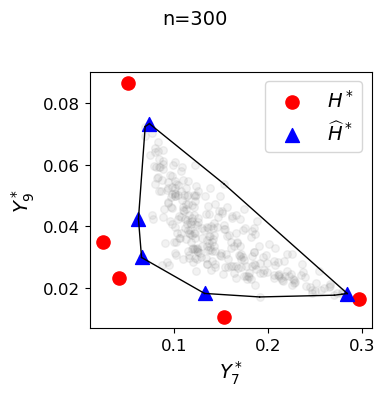

In [17]:
i=8
j=6
plot_single_scatter(Y_star, 
                    i=i, 
                    j=j, 
                    H=H_star, 
                    H_hat=H_star_hat, 
                    alpha=0.1, 
                    title=f"n={n}",
                    # savepath=outdir/f"figure/sourceXray_convergence_sims_iidW_J10K5_HwScatter_i{i}_j{j}_n{n}.pdf"
)

In [18]:
n1 = 100000
seed1 = n1
H_star_hat1 = results[n1]["estimates"]["H_star_hat_sourceXray_10K"][0,:,:]
Y1, Y_star1, r1, H1, H_star1, W1, mu1, W_tilde1, mu_tilde1, W_star1, C1, C_alt1 = simulate_dataset(n=n1, K=K, J=J, seed=seed1, process="iid")

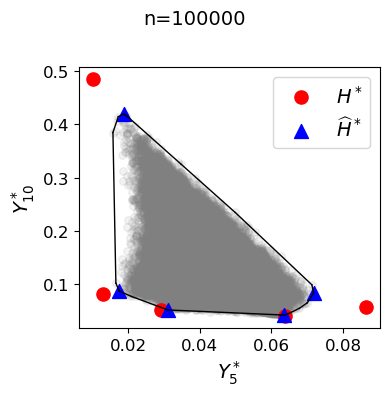

In [19]:
i=9
j=4
plot_single_scatter(Y_star1, 
                    i=i, 
                    j=j, 
                    H=H_star1, 
                    H_hat=H_star_hat1, 
                    alpha=0.1, 
                    title=f"n={n1}",
                    # savepath=outdir/f"figure/sourceXray_convergence_sims_iidW_J10K5_HwScatter_i{i}_j{j}_n{n1}.png"
)

In [20]:
n2 = 500000
seed2 = n2
H_star_hat2 = results[n2]["estimates"]["H_star_hat_sourceXray_10K"][0,:,:]
Y2, Y_star2, r2, H2, H_star2, W2, mu2, W_tilde2, mu_tilde2, W_star2, C2, C_alt2 = simulate_dataset(n=n2, K=K, J=J, seed=seed2, process="iid")

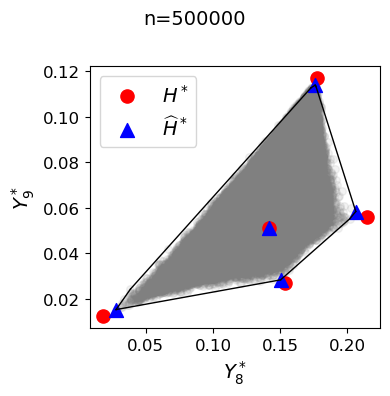

In [21]:
i=8
j=7
plot_single_scatter(Y_star2, 
                    i=i, 
                    j=j, 
                    H=H_star2, 
                    H_hat=H_star_hat2, 
                    alpha=0.1, 
                    title=f"n={n2}",
                    # savepath=outdir/f"figure/sourceXray_convergence_sims_iidW_J10K5_HwScatter_i{i}_j{j}_n{n2}.pdf"
)